# Frozen DINOv2-large — Taxonomy Structure Separation
**Successor of `11_OPN_SHR_structure_separation.ipynb`** (binary shrouded/open — archived).
Now the labels are the full architecture taxonomy, pooled from every 02a-postprocessed
export matching `taxonomy.wizard_excel_glob` (all reviewed batches), one canonical **main image per architecture**
(main architecture only for now).

Each stage answers one question, has explicit pass/fail criteria, and saves its
artefacts to `outputs/analysis_taxonomy/stage<N>/`. A machine-readable
`results.json` and a human `REPORT_11_taxonomy.md` are (re)generated on every run.

| Stage | Question | Pass |
|---|---|---|
| 0 | Are labels, images and embeddings aligned? | 1 row per architecture, 0 unmatched |
| 1 | Are the embeddings valid and non-degenerate? | 0 NaN/Inf/all-zero, cosines not collapsed |
| 2 | Is there non-random global structure? | PC1 ≥ 3× random baseline, organised UMAP |
| 3+ | Clustering / taxonomy alignment / distances / probing | *next iteration* |

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'config.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config_loader import load_config
from src import labels, taxonomy_analysis as tax

cfg  = load_config()
SEED = cfg['analysis']['seed']
BASE = tax.tax_out(cfg)
print('output dir:', BASE)

output dir: /mnt/storage_11tb/Drive_files_to_syncronize/4 - Intelligence Models & Post Process Outputs/Preliminary_analysis/outputs/analysis_taxonomy


## Per-batch stats
Quick sanity check on what's actually pooled from `taxonomy.wizard_excel_glob`
before running the full Stage 0-5 pipeline: how many patents/architectures/
approved images came from each reviewed-batch export, and each batch's
image approval rate.

In [2]:
# Pooled long-format rows, before any pivoting — gives true per-batch counts
# (T1-only disapproved patents still carry a Patent_ID row here, so
# base_patents below is "reviewed", not just "approved").
long_raw = labels.load_long(cfg)
print(f"{len(long_raw)} total rows across {long_raw['_source_file'].nunique()} batch file(s)")

patent_counts = (
    long_raw.assign(base_patent_id=long_raw["Patent_ID"].map(lambda p: labels.parse_arch_id(p)[0]))
    .groupby("_source_file")["base_patent_id"].nunique()
    .rename("base_patents")
)

# 02a's Section 6 export keeps ONLY approved T2 image blocks (disapproved
# figures are dropped entirely, not just flagged) — so this is always a
# count of approved images per batch, not an approve/disapprove split.
img_status = (
    long_raw[(long_raw["Section"] == "T2") & (long_raw["Field"] == "status")]
    .groupby(["_source_file", "Value"]).size().unstack(fill_value=0)
)

batch_stats = patent_counts.to_frame().join(img_status, how="outer")
batch_stats.loc["TOTAL"] = batch_stats.sum(numeric_only=True)
display(batch_stats)

[load_long] pooled 2 file(s): ['Review_postprocess_Batch_01.xlsx', 'Review_postprocess_Batch_05.xlsx']
34257 total rows across 2 batch file(s)


,base_patents,approved
_source_file,,
Review_postprocess_Batch_01.xlsx,352,301
Review_postprocess_Batch_05.xlsx,211,230
TOTAL,563,531


## Stage 0 — Data prep: labels + embeddings + alignment
**Question:** do we have one clean row per architecture — taxonomy labels, an
approved main image, PatSeer metadata, and a DINOv2 embedding — all aligned?
**Input:** wizard long-format xlsx + PatSeer export + main-image PNGs.
**Outputs:** `labels_v1.parquet`, `stage0/coverage_table.csv`, `qc_issues.csv`, `aligned_rows.csv`,
`embeddings/` (extracted here on first run, cached afterwards).
**Pass:** 0 duplicate architectures, 0 unmatched embedding rows.

In [3]:
# schema actually found in the wizard export (documents the input)
schema = labels.inspect_exports(cfg)
display(schema)

prep = tax.stage0_prepare(cfg)
display(prep['qc_issues'])

cov = prep['coverage']
print(f"classes below min_class_count={cfg['taxonomy']['min_class_count']}: "
      f"{int(cov['below_min'].sum())} / {len(cov)}")
display(cov[~cov['below_min']].head(40))   # analyzable classes
display(cov[cov['below_min']].head(40))    # too-small classes (wait for more batches)

[load_long] pooled 2 file(s): ['Review_postprocess_Batch_01.xlsx', 'Review_postprocess_Batch_05.xlsx']
34257 rows | 635 distinct Patent_IDs | 7085 distinct (section, subdim, field) triples


,Section,Sub_Dimension,Field,n_rows
0,G1,Architecture Purity,notPureArch,198
1,G1,G1 — Quick Override,g1_quickOverride,152
2,G1,G1 — Uncertain,g1_humanUncertain,152
3,G1,Topology Type,topType,268
4,M1,Boom Group 1,boom1_attach,61
...,...,...,...,...
7080,T2,Image: imgf0003_crop_0_Fu.png,parts,1
7081,T2,Image: imgf0003_crop_0_Fu.png,per,1
7082,T2,Image: imgf0003_crop_0_Fu.png,qualityFlag,1
7083,T2,Image: imgf0003_crop_0_Fu.png,rotation_deg,1


[load_long] pooled 2 file(s): ['Review_postprocess_Batch_01.xlsx', 'Review_postprocess_Batch_05.xlsx']


/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/DINOv2_eVTOL_frozen_Analysis/src/labels.py:215: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  & ~long["Field"].astype(str).str.contains(DROP_FIELD_RE)].copy()
/home/vasco/anaconda3/envs/Finetune/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


[apply_processing_manifest] 264 image paths -> processed 518px
[build_canonical] 268 architectures (222 base patents, 72 rows in multi-arch patents); 264 have an approved main image.


[save_canonical] wrote labels_v1.parquet/.csv + dictionary to /mnt/storage_11tb/Drive_files_to_syncronize/4 - Intelligence Models & Post Process Outputs/Preliminary_analysis/outputs/analysis_taxonomy


,issue,n,detail
0,architecture without approved main image,4,"CN106585976A, KR102760903B1, US2018354616A1, U..."


classes below min_class_count=15: 420 / 616


,attribute,class,n,null_pct,below_min
0,G1_notPureArch,False,184,26.1,False
2,G1_topType,TP — Vectored Thrust — Tilt Propulsors,87,0.0,False
3,G1_topType,SLC — Independent Thrust — Lift + Cruise,59,0.0,False
4,G1_topType,CVT — Vectored Thrust — Combined,35,0.0,False
5,G1_topType,MR — Wingless — Multirotor,32,0.0,False
14,M1_boom1_attach,Wings — To the Wings,80,50.8,False
15,M1_boom1_attach,Fuselage — To the Fuselage,49,50.8,False
20,M1_boom1_circSym,False,106,58.0,False
22,M1_boom1_count,True,100,50.8,False
27,M1_boom1_hasProps,True,110,55.3,False


,attribute,class,n,null_pct,below_min
1,G1_notPureArch,True,11,26.1,True
6,G1_topType,TW — Vectored Thrust — Tilt Wing,14,0.0,True
7,G1_topType,TB — Vectored Thrust — Tilt Body (Tailsitter),12,0.0,True
8,G1_topType,DS — Vectored Thrust — Deflected Slipstream,10,0.0,True
9,G1_topType,PTC — Vectored Thrust — Pitch-to-Cruise (Winge...,6,0.0,True
10,G1_topType,HB — Other — Hoverbikes,4,0.0,True
11,G1_topType,PFV — Other — Personal Flying Vehicles (PFVs),2,0.0,True
12,G1_topType,SRW — Independent Thrust — Stopped / Slowed Ro...,2,0.0,True
13,G1_topType,RC — Wingless — Rotorcraft,1,0.0,True
16,M1_boom1_attach,Other — Other,1,50.8,True


## Stage 1 — Embedding sanity check
**Question:** are the extracted embeddings valid and non-degenerate?
**Outputs:** `stage1/qc_embedding_report.csv`, `cosine_histograms.png`.
**Pass:** 0 NaN / Inf / all-zero rows in all 6 matrices; per-dimension variance > 0;
cosine distribution not collapsed to a point.

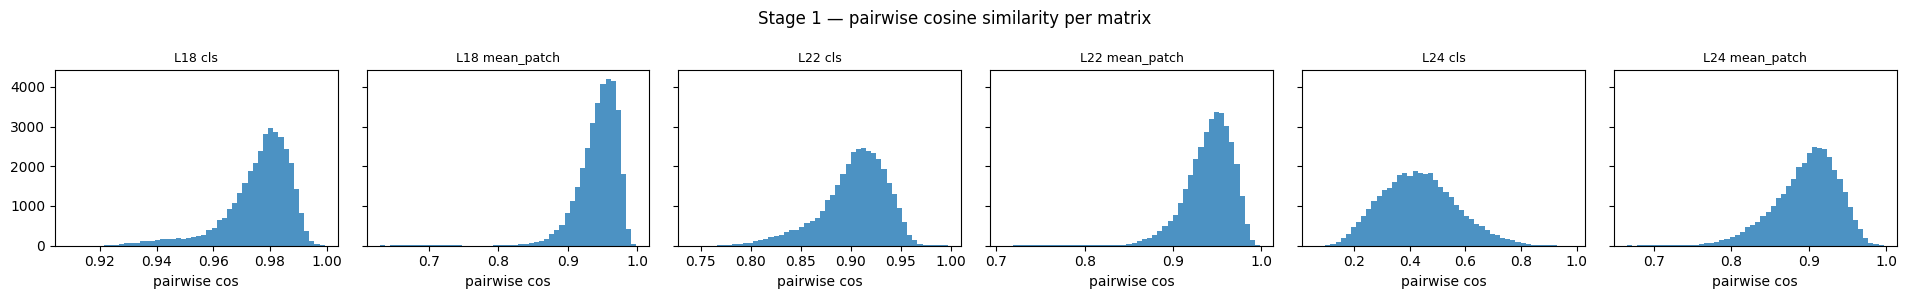

Stage 1 verdict: PASS


,layer,pooling,n_figures,nan_count,inf_count,all_zero_count,exact_duplicate_count,near_dead_dims,dim_var_mean,cos_mean,cos_std,cos_p05,cos_p95
0,18,cls,264,0,0,0,0,0,0.000024,0.975832,0.011814,0.950873,0.989613
1,18,mean_patch,264,0,0,0,0,0,0.000056,0.942109,0.034792,0.890794,0.978279
2,22,cls,264,0,0,0,0,0,0.000094,0.902896,0.033254,0.836920,0.947808
3,22,mean_patch,264,0,0,0,0,0,0.000059,0.939845,0.029405,0.890540,0.976072
4,24,cls,264,0,0,0,0,0,0.000551,0.433687,0.133200,0.226341,0.666608
5,24,mean_patch,264,0,0,0,0,0,0.000101,0.896435,0.041658,0.820122,0.954145


In [4]:
qc = tax.stage1_sanity(prep, cfg)
display(qc[['layer','pooling','n_figures','nan_count','inf_count','all_zero_count',
            'exact_duplicate_count','near_dead_dims','dim_var_mean',
            'cos_mean','cos_std','cos_p05','cos_p95']])

## Stage 2 — Global structure
**Question:** do the embeddings contain non-random structure at all?
**Method:** PCA spectrum vs matched random-Gaussian baseline; pairwise-distance
distribution vs random; intrinsic dimensionality (participation ratio); Hopkins
clustering tendency; UMAP re-colored by each major taxonomy attribute.
**Outputs:** `stage2/pca_stats.csv`, `pca_vs_random.png`, `random_baseline_comparison.png`, `umap_by_attribute.png`.
**Pass:** PC1 ≥ 3× random baseline; distance distribution clearly wider than random; Hopkins > 0.5.
**Fail:** spectrum and distances indistinguishable from random.

I0000 00:00:1783355209.582865 3407252 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


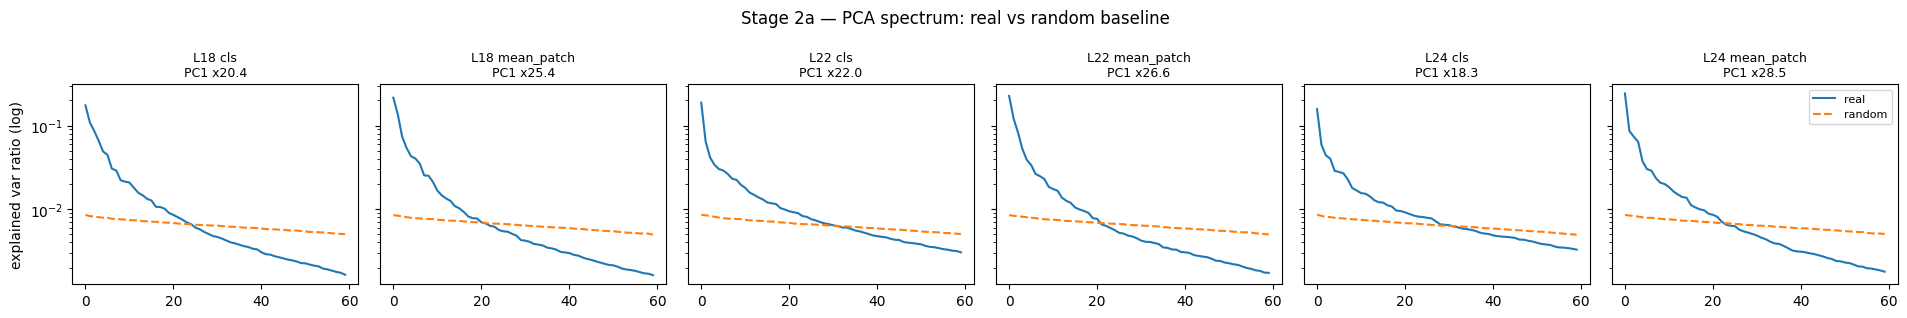

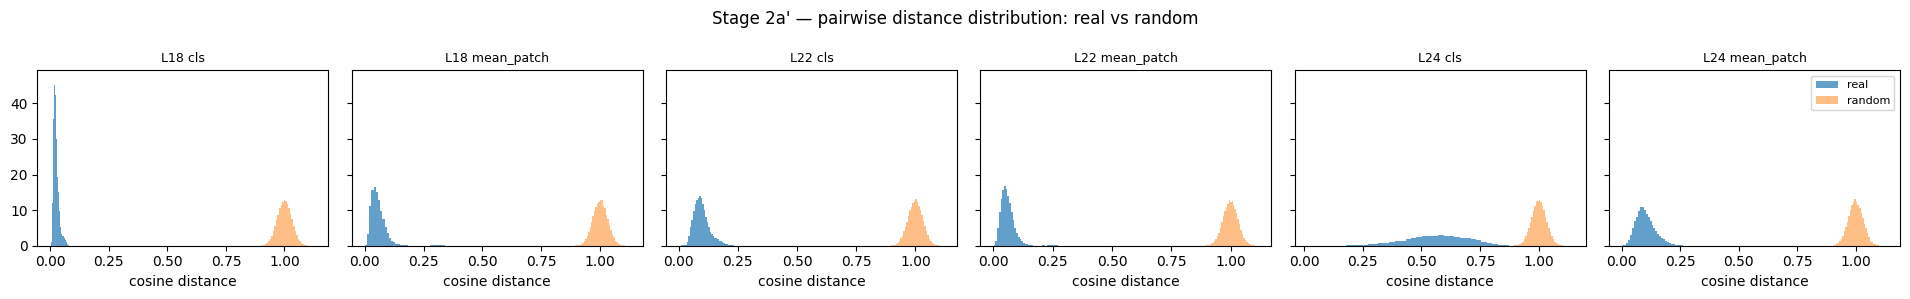

/home/vasco/anaconda3/envs/Finetune/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


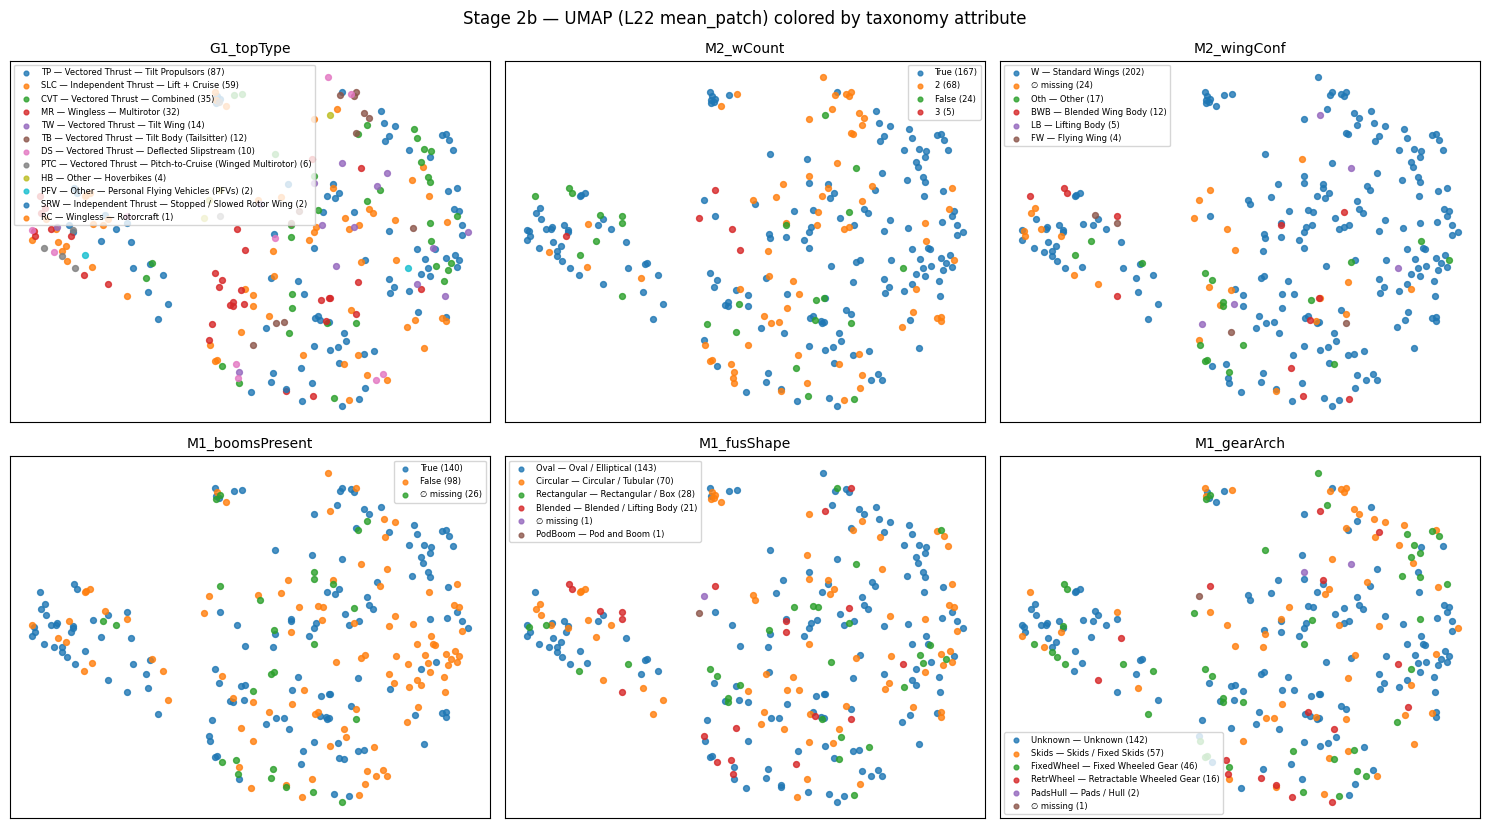

,layer,pooling,pc1_var,pc1_random,pc1_ratio_vs_random,dims_for_90pct,participation_ratio,hopkins
0,18,cls,0.174321,0.008533,20.430094,52,15.7,0.683
1,18,mean_patch,0.215294,0.008469,25.420241,51,12.2,0.718
2,22,cls,0.187954,0.008541,22.007170,61,20.2,0.706
3,22,mean_patch,0.225686,0.008493,26.573677,57,12.1,0.687
4,24,cls,0.157190,0.008602,18.274085,61,26.0,0.724
5,24,mean_patch,0.242334,0.008507,28.488026,57,12.1,0.664


In [5]:
pca_stats = tax.stage2_global_structure(prep, cfg)
display(pca_stats)

## Stage 3 — Unsupervised clustering
**Question:** do coherent groups emerge without using any taxonomy label?
**Method:** PCA to 90%-variance dims, then k-means (k sweep) / agglomerative (ward) / HDBSCAN;
bootstrap-ARI stability of the best k-means partition; dendrogram cut at best k.
**Outputs:** `stage3/cluster_metrics.csv`, `cluster_labels.csv`, `cluster_sizes.csv`, `dendrogram.png`, `umap_clusters.png`.
**Pass:** silhouette > 0.10, bootstrap ARI > 0.60, no extreme fragmentation / one giant cluster.
**Fail:** all noise, one dominant cluster, or unstable partitions.

[stage3] reference L22 mean_patch -> PCA 57 dims (90% var)


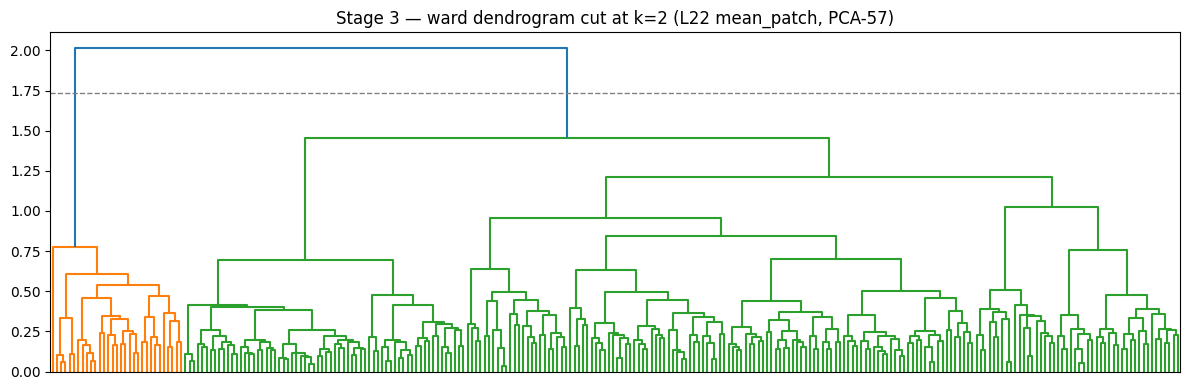

/home/vasco/anaconda3/envs/Finetune/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


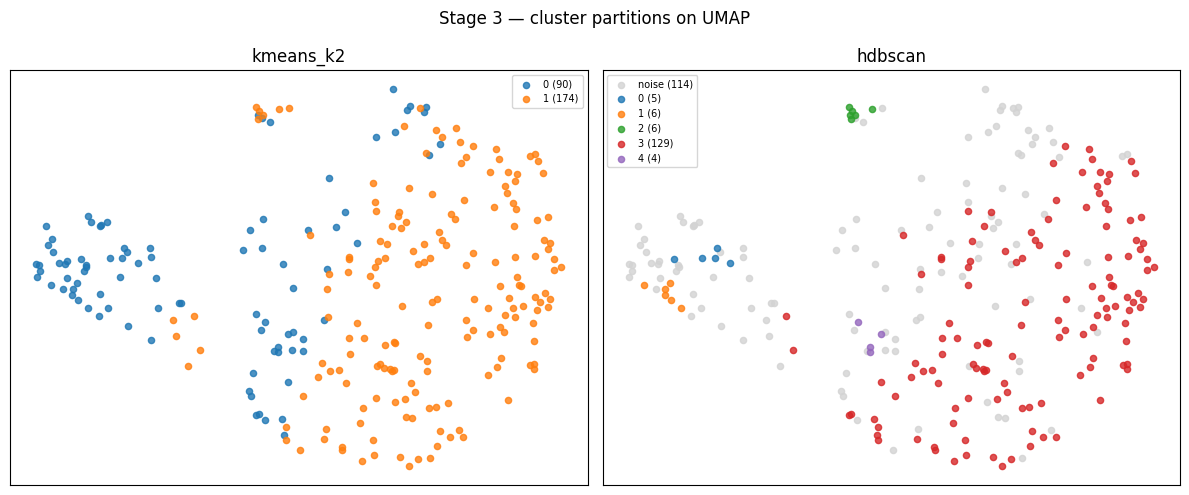

,method,k,silhouette,davies_bouldin,calinski_harabasz,noise_frac
1,agglomerative,2,0.253907,1.527523,43.346924,0.000000
0,kmeans,2,0.196723,2.080031,54.763866,0.000000
14,hdbscan,5,0.149474,1.272721,12.394145,0.431818
4,kmeans,4,0.135204,2.174713,38.208027,0.000000
6,kmeans,5,0.134841,2.120784,32.943039,0.000000
2,kmeans,3,0.134531,2.190499,44.708820,0.000000
12,kmeans,10,0.103891,2.203543,20.611589,0.000000
10,kmeans,8,0.102946,1.903815,24.408092,0.000000
8,kmeans,6,0.096530,2.211818,29.459103,0.000000
13,agglomerative,10,0.095798,2.084151,20.418900,0.000000


,partition,n_clusters,sizes,n_noise,largest_frac
0,kmeans_k2,2,90/174,0,0.66
1,agglomerative_k2,2,233/31,0,0.88
2,kmeans_k3,3,50/111/103,0,0.42
3,agglomerative_k3,3,167/31/66,0,0.63
4,kmeans_k4,4,102/41/48/73,0,0.39
5,agglomerative_k4,4,48/119/66/31,0,0.45
6,kmeans_k5,5,67/95/27/45/30,0,0.36
7,agglomerative_k5,5,119/31/66/29/19,0,0.45
8,kmeans_k6,6,54/33/29/56/63/29,0,0.24
9,agglomerative_k6,6,95/31/66/29/19/24,0,0.36


In [6]:
metrics3 = tax.stage3_clustering(prep, cfg)
display(metrics3)
import pandas as pd
display(pd.read_csv(BASE / 'stage3' / 'cluster_sizes.csv'))

## Stage 4 — Are the clusters meaningful?
**Question:** do the Stage-3 clusters line up with the taxonomy — or with confounds
(assignee, year, perspective, drawing style)?
**Method:** purity / NMI / ARI of every testable attribute (≥2 classes with ≥5 rows)
and every confound vs the best k-means partition; per-cluster enrichment for the top attributes.
**Outputs:** `stage4/cluster_label_alignment.csv`, `cluster_enrichment.csv`, `alignment_nmi.png`.
**Pass:** best taxonomy attribute out-aligns every confound.
**Fail:** assignee / style aligns at least as well — clusters reflect drawing style, not design.

[stage4] 79 testable attributes + 9 confounds + 2 external labels against partition kmeans_k2


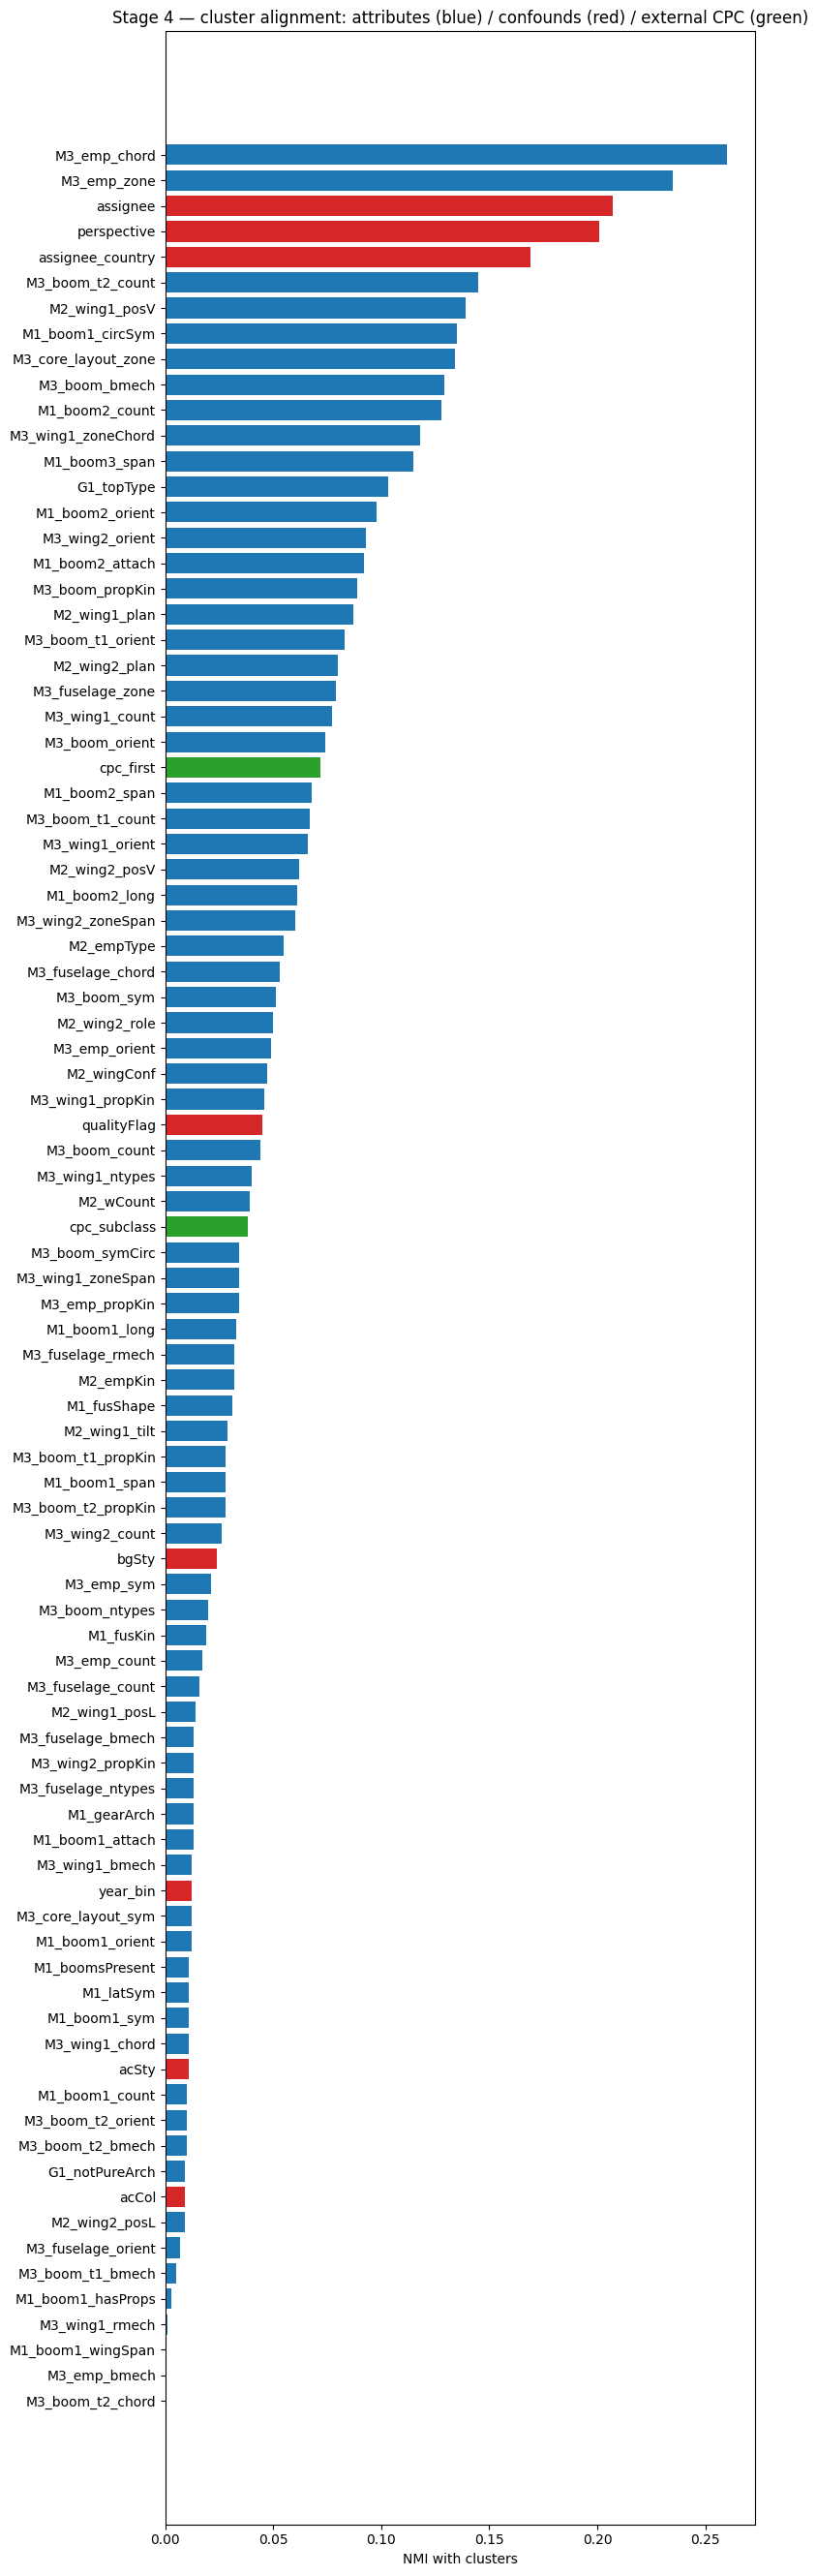

,name,kind,n,n_classes,purity,nmi,ari
0,M3_emp_chord,attribute,39,2,0.744,0.260,0.218
1,M3_emp_zone,attribute,41,5,0.707,0.235,0.123
2,assignee,confound,264,109,0.167,0.207,0.036
3,perspective,confound,264,6,0.731,0.201,0.288
4,assignee_country,confound,261,19,0.521,0.169,0.182
5,M3_boom_t2_count,attribute,94,9,0.691,0.145,-0.013
6,M2_wing1_posV,attribute,211,4,0.725,0.139,0.210
7,M1_boom1_circSym,attribute,111,2,0.955,0.135,0.109
8,M3_core_layout_zone,attribute,14,3,0.429,0.134,-0.051
9,M3_boom_bmech,attribute,42,2,0.881,0.129,-0.030


,attribute,cluster,n,dominant_class,dominant_share
0,M3_emp_chord,0,14,Back — Back (Pusher),0.93
1,M3_emp_chord,1,25,Front — Front (Puller / Tractor),0.64
2,M3_emp_zone,0,14,Tip — Tip Mounted,0.57
3,M3_emp_zone,1,27,Tip — Tip Mounted,0.78
4,M3_boom_t2_count,0,39,2,0.79
5,M3_boom_t2_count,1,55,2,0.62
6,M2_wing1_posV,0,56,High — High / Hub,0.48
7,M2_wing1_posV,1,155,High — High / Hub,0.81
8,M1_boom1_circSym,0,35,False,0.86
9,M1_boom1_circSym,1,76,False,1.00


In [7]:
align4 = tax.stage4_alignment(prep, cfg)
display(align4.head(25))
import pandas as pd
enrich = pd.read_csv(BASE / 'stage4' / 'cluster_enrichment.csv')
display(enrich)

## Stage 5 — Intra- vs inter-class distances (+ layer comparison)
**Question:** are same-class patents genuinely closer than different-class patents —
and which layer/pooling sees each attribute best?
**Method:** for every testable attribute and the Stage-3 clusters, on **all 6 matrices**:
separation ratio (inter/intra mean cosine distance), Cohen's d, label-permutation p-value (1000 perms).
**Outputs:** `stage5/intra_inter_distance_stats.csv`, `separation_heatmap.png`.
**Pass:** several attributes with sep_ratio > 1 at p < 0.05.
**Fail:** ratios ≈ 1 everywhere — class geometry is arbitrary.

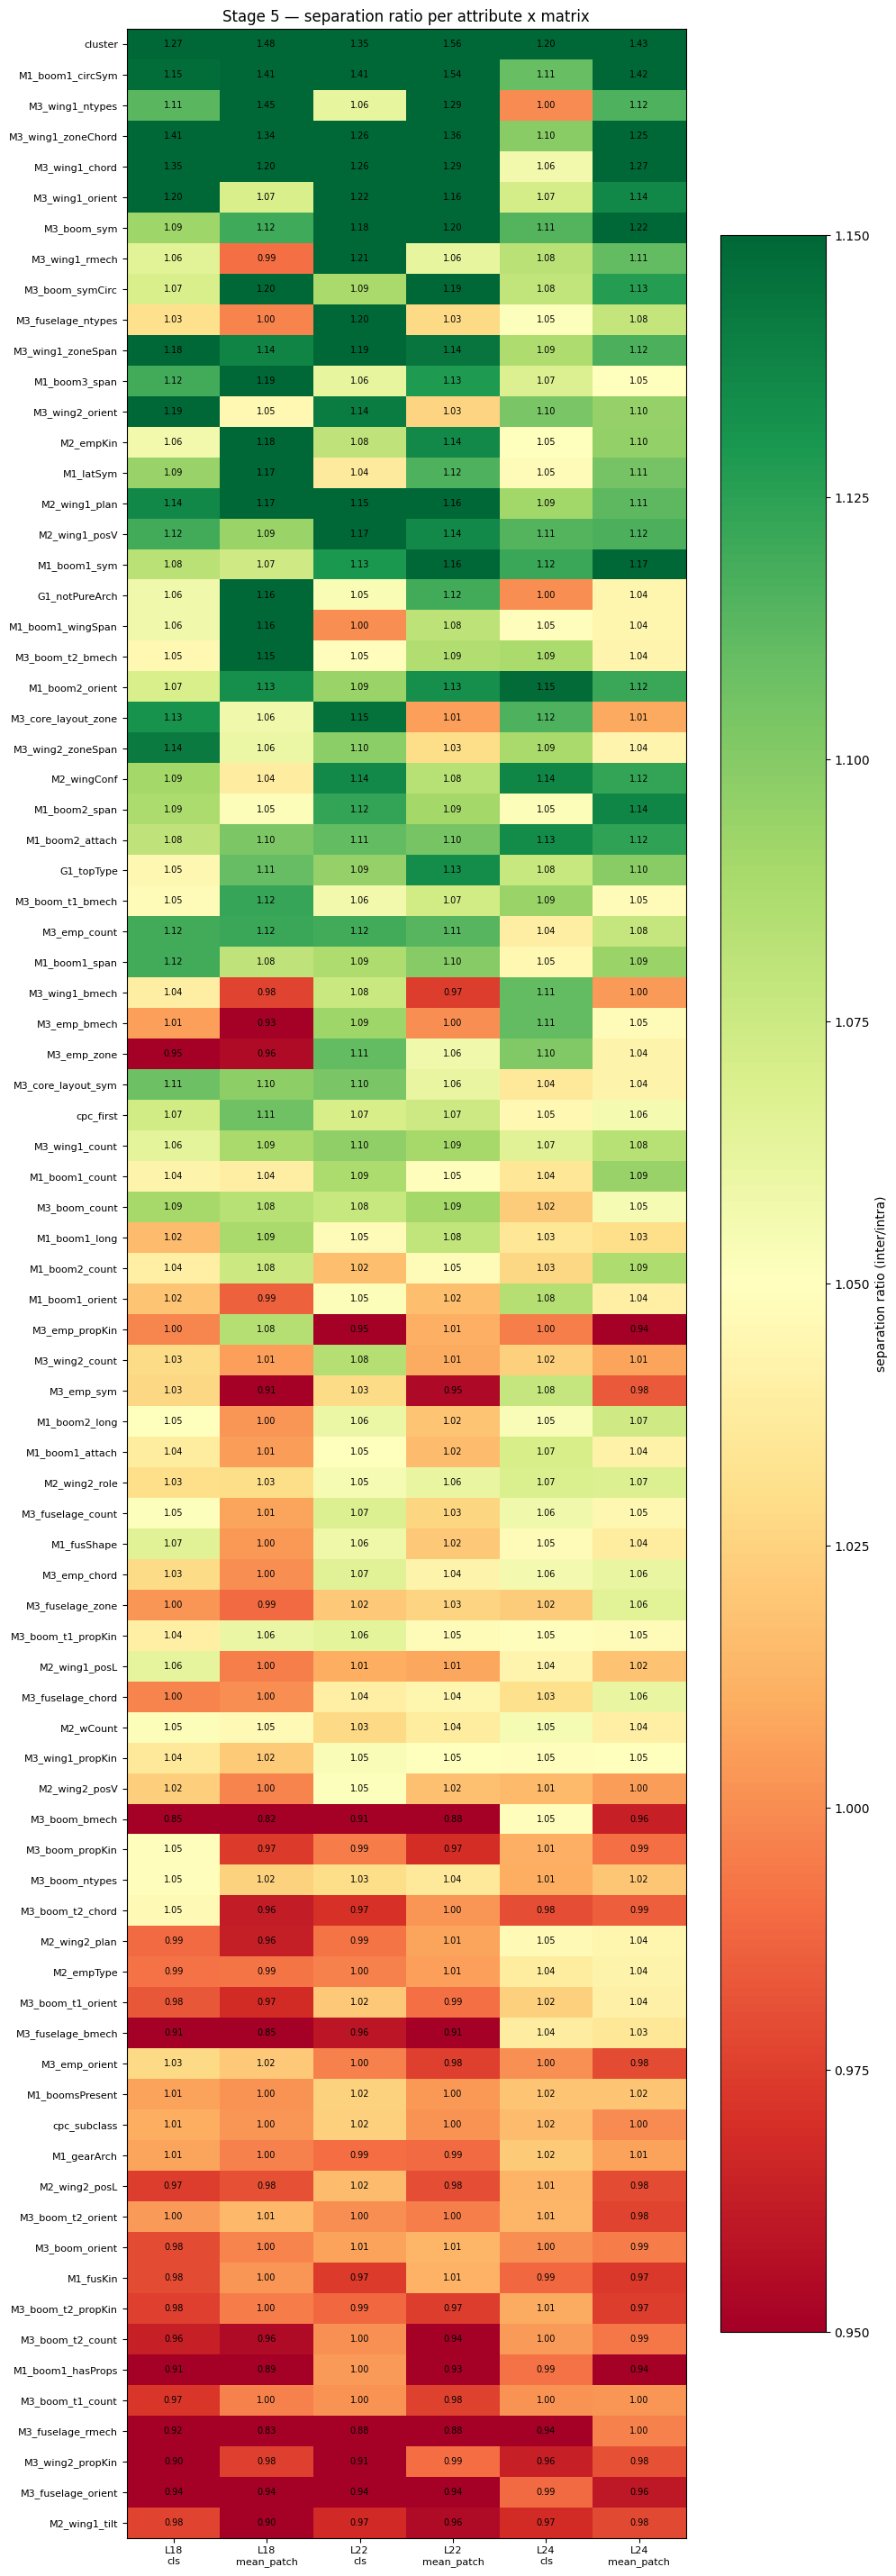

,name,layer,pooling,n,sep_ratio,cohens_d,p_value,intra_mean,inter_mean
0,cluster,22,mean_patch,264,1.560348,1.027725,0.000999,0.048018,0.074925
1,M1_boom1_circSym,22,mean_patch,111,1.542732,1.248313,0.000999,0.055624,0.085813
2,M3_wing1_ntypes,18,mean_patch,211,1.452323,0.673510,0.009990,0.053288,0.077391
3,M3_wing1_zoneChord,18,cls,143,1.407574,0.628338,0.000999,0.017860,0.025139
4,M3_wing1_chord,18,cls,119,1.345907,0.636514,0.022977,0.018895,0.025431
5,M3_wing1_orient,22,cls,119,1.223805,0.586774,0.000999,0.072760,0.089044
6,M3_boom_sym,24,mean_patch,260,1.215640,0.526988,0.001998,0.100911,0.122671
7,M3_wing1_rmech,22,cls,119,1.210001,0.575260,0.006993,0.077319,0.093557
8,M3_boom_symCirc,18,mean_patch,179,1.196315,0.405450,0.054945,0.049953,0.059759
9,M3_fuselage_ntypes,22,cls,211,1.195041,0.538913,0.016983,0.089380,0.106813


In [8]:
best5 = tax.stage5_distances(prep, cfg)
display(best5.head(25))

## Report
`results.json` + `REPORT_11_taxonomy.md` summarise every stage that ran above.

In [9]:
tax.write_report(cfg)
import json
print(json.dumps(json.loads((BASE / 'results.json').read_text()), indent=2)[:3000])

[write_report] /mnt/storage_11tb/Drive_files_to_syncronize/4 - Intelligence Models & Post Process Outputs/Preliminary_analysis/outputs/analysis_taxonomy/REPORT_11_taxonomy.md
{
  "stage0": {
    "name": "data prep (labels + embeddings + alignment)",
    "run_date": "2026-07-06",
    "n_architectures_labelled": 268,
    "n_base_patents": 222,
    "n_multi_arch_rows": 72,
    "n_rows_embedded": 264,
    "n_attributes": 256,
    "n_classes_below_min": 420,
    "qc_issues": {
      "architecture without approved main image": 4
    }
  },
  "stage1": {
    "name": "embedding sanity check",
    "run_date": "2026-07-06",
    "pass": true,
    "n_figures": 264,
    "exact_duplicates_max": 0,
    "near_dead_dims_max": 0,
    "cos_std_min": 0.011814061670827655,
    "verdict": "PASS \u2014 embeddings valid"
  },
  "stage2": {
    "name": "global structure (PCA vs random, UMAP)",
    "run_date": "2026-07-06",
    "pc1_ratio_vs_random": {
      "L18_cls": 20.43,
      "L18_mean_patch": 25.42,
    

## Stage 6+ — next iteration
Planned:
- **Stage 6** supervised linear probing per attribute (k-NN + logistic on PCA-50, GroupKFold by base patent, vs majority + shuffled baselines)
- **Stage 7** temporal / genealogical signal (needs more labelled batches)
